## Observation Planning for proposals 

CTAO will conduct observations based on competitive proposals requesting time. 
This tutorial will enable you to complete the sections of an observation proposal concerning the observation parameters and the technical justification.

To start with, we assume that you already know a) the science case for gamma-ray emission, b) a specific target located on the sky, and c) the anticipated gamma-ray flux. 

We will now address the following questions:
1. Is the source visible by CTAO-N/CTAO-S?
2. How much time do I need to reach a 5$\sigma$ detection?
3. What role do the zenith angle and Night Sky Background play? 
4. How do I determine a good observation strategy?
5. What total observation time should be requested? 

### 1: visibility

In this notebook we address the issue of target visibility from the CTAO locations

In [1]:
#First import some useful packages
import numpy as np
import astropy.units as u
from astropy.time import Time, TimeDelta
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import MaxNLocator
from matplotlib.lines import Line2D
mpl.use('Agg')
from mpl_toolkits.axes_grid1 import make_axes_locatable
import pandas as pd
import healpy as hp
from astropy.coordinates import EarthLocation,SkyCoord,AltAz,Galactic, ICRS
import matplotlib.gridspec as gridspec
from healpy.newvisufunc import projview

%matplotlib inline

In [2]:
#Define some functions useful for making an observability plot

def cat2hpx(lon, lat, nside, radec=True):
    """
    Convert a catalogue to a HEALPix map of number counts per resolution element.

    Parameters
    ----------
    lon, lat : (ndarray, ndarray)
        Coordinates of the sources in degree. If radec=True, assume input is in the icrs
        coordinate system. Otherwise assume input is glon, glat
    nside : int
        HEALPix nside of the target map
    radec : bool
        Switch between R.A./Dec and glon/glat as input coordinate system.

    Return
    ------
    hpx_map : ndarray
        HEALPix map of the catalogue number counts in Galactic coordinates

    """

    npix = hp.nside2npix(nside)

    if radec:
        eq = SkyCoord(lon, lat, frame='icrs', unit='deg')
        l, b = eq.galactic.l.value, eq.galactic.b.value
    else:
        l, b = lon, lat

    # conver to theta, phi
    theta = np.radians(90. - b)
    phi = np.radians(l)

    # convert to HEALPix indices
    indices = hp.ang2pix(nside, theta, phi)

    idx, counts = np.unique(indices, return_counts=True)

    # fill the fullsky map
    hpx_map = np.zeros(npix, dtype=int)
    hpx_map[idx] = counts

    return hpx_map


def pixarea2nside(area):
    """Closest HEALPix nside for a given area, taken from desitarget.
    Parameters
    ----------
    area : :class:`float`
        area in square degrees.
    Returns
    -------
    :class:`int`
        HEALPix nside that corresponds to passed area.
    Notes
    -----
        - Only considers 2**x nside values (1, 2, 4, 8 etc.)
    """
    # ADM loop through nsides until we cross the passed area.
    nside = 1
    while (hp.nside2pixarea(nside, degrees=True) > area):
        nside *= 2

    # ADM there is no nside of 0 so bail if nside is still 1.
    if nside > 1:
        # ADM is the nside with the area that is smaller or larger
        smaller = hp.nside2pixarea(nside, degrees=True)
        larger = hp.nside2pixarea(nside//2, degrees=True)
        if larger/area < area/smaller:
            return nside//2

    return nside


<Figure size 1000x600 with 0 Axes>

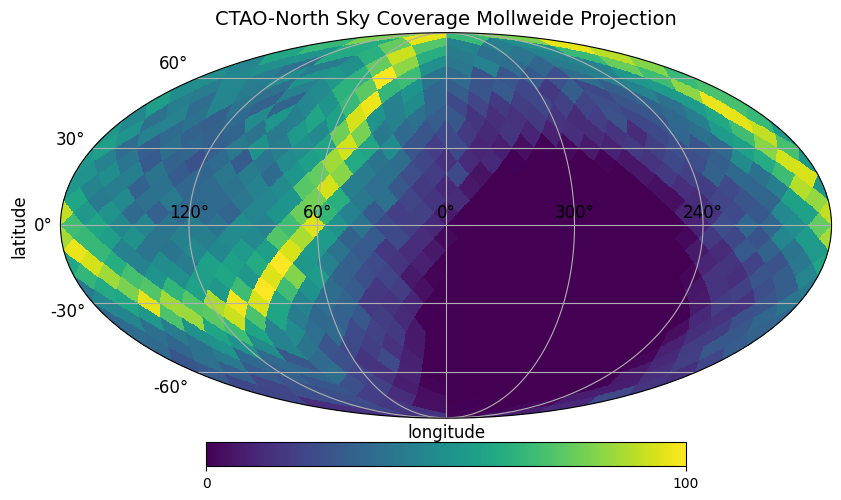

In [3]:
def calcobserve():
    '''Random Pointing generator for La Palma'''
    noyears=5    #Number of years
    nbins = 8760 
    azs=np.random.randint(0,360,size=nbins*noyears)*u.deg #360 degrees azimuth
    alts=np.random.randint(30,90,size=nbins*noyears)*u.deg #minimum 30 degrees elevation
    #CTAO-North, La Palma:
    loc = EarthLocation.from_geodetic(lon=-17.892,lat=28.762,height=2200.*u.m)
    #CTAO-South, Paranal: 
    # loc = EarthLocation.from_geodetic(lon=-70.316,lat=-24.683,height=2100.*u.m)
    dt=TimeDelta(3600,format='sec')
    obstimes=Time("2024-01-01T00:01:01.0")+np.random.randint(0,nbins*noyears,size=nbins*noyears)*dt
    skycoords=AltAz(az=azs,alt=alts,location=loc,obstime=obstimes)
    skycoords=skycoords.transform_to(ICRS())

    return skycoords

#Now make the plot 
if __name__=='__main__':
    NSIDE=8
#     print('Appropriate NSIDE to use',pixarea2nside(52.524))
    fig=plt.figure(figsize=(10,6))
    randopoint=calcobserve()
    avmap=cat2hpx(randopoint.ra,randopoint.dec,NSIDE,radec=True)
    coverage=np.zeros(np.shape(avmap))
    covlocs=np.where(avmap>0)
    #Check which positions are covered - set these to 1
    coverage[covlocs]=1
    percent = 100.*avmap/max(avmap)
#     hp.graticule()
    projview(percent, coord=["G"], graticule=True, graticule_labels=True, xlabel="longitude",ylabel="latitude",
             cb_orientation="horizontal",title='CTAO-North Sky Coverage Mollweide Projection',projection_type="mollweide")
    # plt.savefig('CTAO-N_skycoveragetest.png')

    None

#### Check if a source is observable from La Palma
To do this, we check with the source location is covered at least once (i.e. coverage > 0) in the above sky map

In [4]:
crab = SkyCoord.from_name('Crab')

def check_vis(src_coord):
    #Convert galactic coordinates into pixel coordinates: 
    test_loc = cat2hpx(src_coord.galactic.l.deg,src_coord.galactic.b.deg,8,radec=False)
    testidx = np.where(test_loc>0)[0]

    #Check the values of coverage and avmap at the source location
    if coverage[testidx[0]] > 0.:
        print("Observable")
        print(coverage[testidx[0]],percent[testidx[0]])
        return True
    else:
        print("Not observable")
        print(coverage[testidx[0]],percent[testidx[0]])
        return False
    
#Note: the higher the value of avmap, the longer the available time per year / higher max elevation reached.
check_vis(crab)

Observable
1.0 54.01069518716577


True

In [5]:
#An alternative method to obtain a location
LaPalmaLoc = EarthLocation.of_site("lapalma")
CTAO_N = EarthLocation.from_geodetic(lon=-17.892,lat=28.762,height=2200.*u.m) #CTAO-N location
CTAO_S = EarthLocation.from_geodetic(lon=-70.316,lat=-24.683,height=2100.*u.m) #CTAO-S location

OK, we've established that the Crab can be observed from CTAO-North. 

Now let's consider the observability for a particular night - how about tonight? 

In [6]:
from astropy.coordinates import get_sun, get_body

midnight = Time('2026-05-28 00:00:00')
delta_midnight = np.linspace(-12, 12, 1000)*u.hour
times_night = midnight + delta_midnight
frame_night = AltAz(obstime=times_night, location=CTAO_N)

#Check the sun and moon as well
sunaltazs_night = get_sun(times_night).transform_to(frame_night)
moonaltaz_night = get_body("moon",times_night).transform_to(frame_night)
crabaltaz_night = crab.transform_to(frame_night)

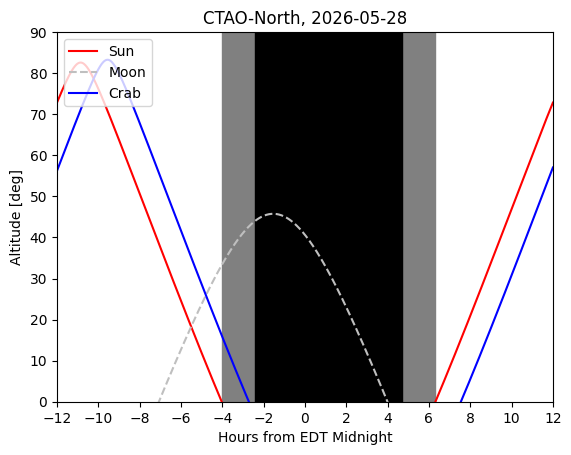

In [7]:
#Make a nice plot for the observability tonight

plt.plot(delta_midnight, sunaltazs_night.alt, color='r', label='Sun')
plt.plot(delta_midnight, moonaltaz_night.alt, color=[0.75]*3, ls='--', label='Moon')
plt.plot(delta_midnight, crabaltaz_night.alt,color='b',label='Crab')

plt.fill_between(delta_midnight.value, 0., 90.,
                 sunaltazs_night.alt < -0*u.deg, color='0.5', zorder=0)
plt.fill_between(delta_midnight.value, 0., 90.,
                 sunaltazs_night.alt < -18*u.deg, color='k', zorder=0)

plt.legend(loc='upper left')
plt.xlim(-12., 12.)
plt.xticks((np.arange(13)*2-12))
plt.ylim(0., 90.)
plt.xlabel('Hours from EDT Midnight')
plt.ylabel('Altitude [deg]')
plt.title("CTAO-North, 2026-05-28")

# plt.savefig("CrabVisibility_CTAO-N.png",dpi=250)

None

Oh dear, it seems that we can't observe the Crab tonight, as it is only above the horizon during daylight. 

But, we already know that the Crab can be observed by CTAO-North as the coverage is non-zero. 

When? Let's check the visibility over a year. 

In [8]:
#Plotting in offsets of days - always at midnight
delta_year = np.linspace(-200, 200, 401)*u.day
times_year = midnight + delta_year
frame_year = AltAz(obstime=times_year, location=CTAO_N)

sunaltazs_year = get_sun(times_year).transform_to(frame_year)
moonaltaz_year = get_body("moon",times_year).transform_to(frame_year)
crabaltaz_year = crab.transform_to(frame_year)

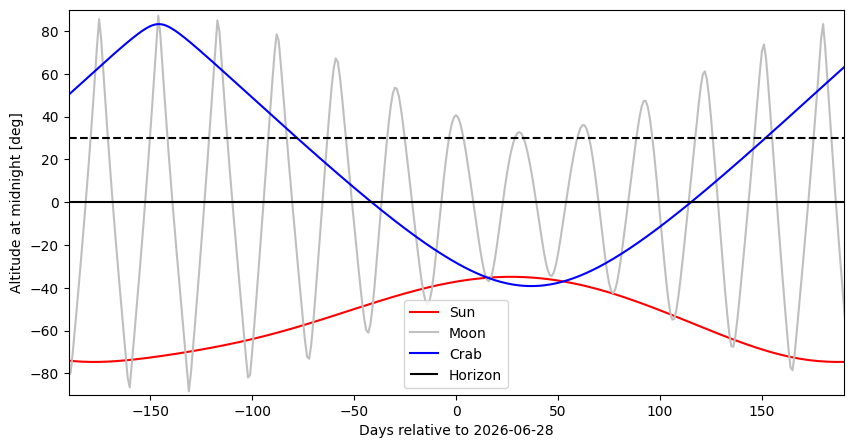

In [9]:
plt.figure(figsize=(10,5))
plt.plot(delta_year, sunaltazs_year.alt, color='r', label='Sun')
plt.plot(delta_year, moonaltaz_year.alt, color=[0.75]*3,label='Moon')
plt.plot(delta_year, crabaltaz_year.alt,color='b',label='Crab')

plt.xlim(-190., 190.)
plt.ylim(-90., 90.)
plt.hlines(y=0.,xmin=-190.,xmax=190.,color="k",label="Horizon")

#Use 30 degrees as a minimum altitude above the horizon from which a source becomes observable
plt.hlines(y=30.,xmin=-190.,xmax=190,color="k",linestyles="--")
plt.legend(loc='lower center')
plt.xlabel('Days relative to 2026-06-28')
plt.ylabel('Altitude at midnight [deg]')
# plt.title("La Palma, 2026")

# plt.savefig("CrabVisibility_CTAO-North_2026.png",dpi=250)

None

OK, this looks more promising. If we wait a few months, then the Crab rises above the horizon at night again. 
Let's find out how long we have to wait:

In [10]:
#Use an interpolation to find the dates at which the Crab is above the horizon
from scipy.interpolate import interp1d

crab_alts = interp1d(delta_year,crabaltaz_year.alt.deg)

#Find when Crab will rise sufficiently high again
for d in range(180):
    if crab_alts(d)>30.:
        print(d)
        break
    else:
        continue
        

152


In [11]:
(midnight+152.*u.day).value

'2026-10-27 00:00:00.000'

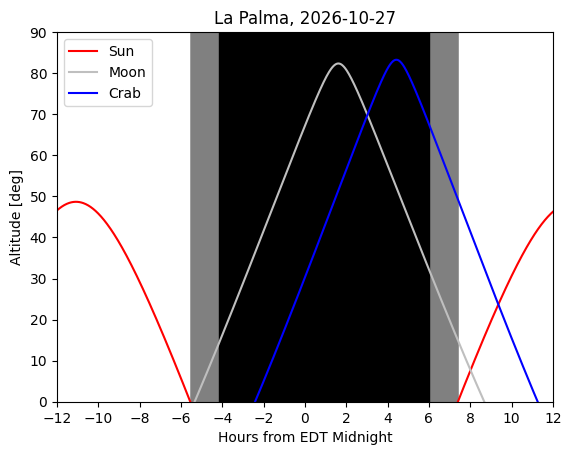

In [12]:
#Make a nice plot for the observability on 27th October
times_oct = midnight + 152.*u.day + delta_midnight
frame_oct = AltAz(obstime=times_oct, location=CTAO_N)
sunaltazs_oct = get_sun(times_oct).transform_to(frame_oct)
moonaltaz_oct = get_body("moon",times_oct).transform_to(frame_oct)
crabaltaz_oct = crab.transform_to(frame_oct)

plt.plot(delta_midnight, sunaltazs_oct.alt, color='r', label='Sun')
plt.plot(delta_midnight, moonaltaz_oct.alt, color=[0.75]*3, label='Moon')
plt.plot(delta_midnight, crabaltaz_oct.alt,color='b',label='Crab')

plt.fill_between(delta_midnight.value, 0., 90.,
                 sunaltazs_oct.alt < -0*u.deg, color='0.5', zorder=0)
plt.fill_between(delta_midnight.value, 0., 90.,
                 sunaltazs_oct.alt < -18*u.deg, color='k', zorder=0)

plt.legend(loc='upper left')
plt.xlim(-12., 12.)
plt.xticks((np.arange(13)*2-12))
plt.ylim(0., 90.)
plt.xlabel('Hours from EDT Midnight')
plt.ylabel('Altitude [deg]')
plt.title("La Palma, 2026-10-27")

# plt.savefig("CrabVisibility_CTAO-N_Oct.png",dpi=250)

None

From this we see that the "altitude at midnight" alone is not sufficient to determine if a source will be observable *at all* , because the Crab is observable on earlier nights in october just at later times. Additionally, the altitude of the moon complicates the picture. 

For completeness, times during the night over many days must be taken into account. 

Now let's try another source that might be visible at this time of year.

In [13]:
#Galactic centre
GC = SkyCoord.from_name('SgrA*')

print(GC.transform_to(frame="galactic"))
print(check_vis(GC))

gcaltaz_year = GC.transform_to(frame_year)

<SkyCoord (Galactic): (l, b) in deg
    (359.94423568, -0.04616002)>
Observable
1.0 0.5347593582887701
True


As we know that the Crab should be visible sooner than October but rising later in the night, let's check the visibility at 2am. 


In [14]:
two_am = Time('2026-05-28 02:00:00')
times_two_year = two_am + delta_year
frame_two_year = AltAz(obstime=times_two_year, location=CTAO_N)
crabaltaz_two_year = crab.transform_to(frame_two_year)

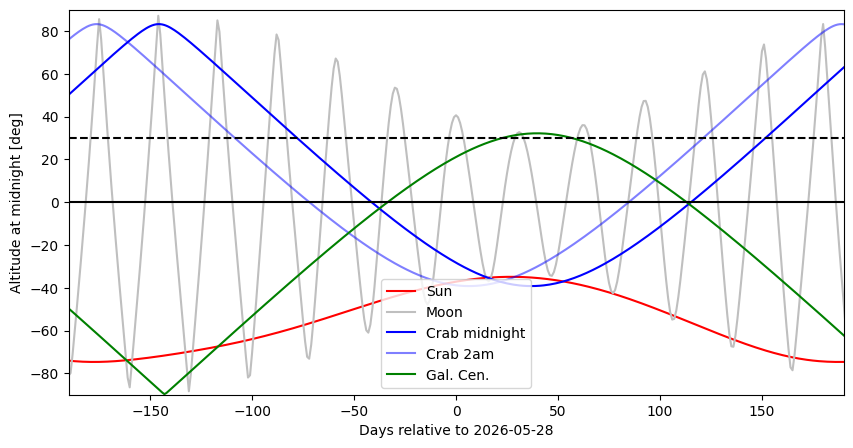

In [15]:
plt.figure(figsize=(10,5))
plt.plot(delta_year, sunaltazs_year.alt, color='r', label='Sun')
plt.plot(delta_year, moonaltaz_year.alt, color=[0.75]*3,label='Moon')
plt.plot(delta_year, crabaltaz_year.alt,color='b',label='Crab midnight')
plt.plot(delta_year, crabaltaz_two_year.alt,color='b',alpha=0.5,label='Crab 2am')
plt.plot(delta_year, gcaltaz_year.alt,color='g',label='Gal. Cen.')

plt.xlim(-190., 190.)
plt.ylim(-90., 90.)
plt.hlines(y=0.,xmin=-190.,xmax=190.,color="k")#,label="Horizon")

#Use 30 degrees as a minimum altitude above the horizon from which a source becomes observable
plt.hlines(y=30.,xmin=-190.,xmax=190,color="k",linestyles="--")
plt.legend(loc='lower center')
plt.xlabel('Days relative to 2026-05-28')
plt.ylabel('Altitude at midnight [deg]')

None

### Visibility tools available online

The following interactive visibility tools are available online to help with planning, indicating the available hours per year. 
* TeVCat: http://tevcat.uchicago.edu/CustomVis.pl 
* H.E.S.S.: https://www.mpi-hd.mpg.de/hfm/HESS/pages/home/visibility/ 
* MAGIC: http://www.magic.iac.es/scheduler/

**Task**: Look up the observability of your favourite source from more than one site. 
How many hours are available per year? 
Make a plot of its observability by CTAO *tonight*, try comparing the Northern and Southern sites.  